In [2]:
#Titanic: Machine Learning from Disaster
#Prevendo os sobreviventes com a utilização de Regressão Linear
#Solução para a competição "Titanic: Machine Learning from Disaster" utilizando Regressão Linear.
#A análise abaixo é de caráter exploratório, apenas para aprender o básico da importação e tratamento de dados no Python, além de demonstrar que o método de Regressão Linear pode ser poderoso e ao mesmo tempo de simples implementação.
#Carlos Melo 
#Definição do problema
#O naufrágio do Titanic foi um dos maiores desastres na história. Ocorrido em 15 de abril de 1912, após uma colisão com um iceberg, o navio afundou. O saldo final da tragédia foi um total de 1502 mortos de um total de 2224 pessoas (incluindo passageiros e tripulação). Um dos motivos para o grande número de vítimas (cerca de 68%) diz respeito à
#quantidade de botes bem inferior ao mínimo que seria necessário.
#Nessa situação, apesar do fator "sorte" ter feito parte na sobrevivência dos passageiros do Titanic, existiram grupos de pessoas que tinham uma maior probabilidade de escaparem da morte (como por exemplo mulheres, crianças e passageiros viajando na primeira-classe), como informa a descrição do próprio desafio.
#Dentro desse contexto, o site Kaggle fornece então um conjunto de dados aos competidores do desafio, contendo algumas informações (nome, idade, sexo, sobreviveu(sim/não), etc.) sobre 891 passageiros. É esperado que o competidor conduza uma análise e crie um modelo capaz de prever, com a maior acurácia possível, a condição de sobrevivência para os passageiros restantes (dataset de teste).
#Um vídeo com a descrição do acidente do Titanic pode ser visto no link abaixo.
#TITANIC sinking
#Aquisição dos dados
#O Kaggle fornece os dados no formato'.csv'. Os mesmos são divididos em:
#conjunto de treinamento (train.csv): para ser utilizado para construir os modelos de machine learning. Neste arquivo, é conhecido se cada passageiro sobreviveu ou não.
#conjunto de teste (test.csv): para verificar o quão bom o modelo construido é com dados não observados até então. Neste aqruivo, não é fornecida a condição de sobrevivência para cada passageiro. O modelo construído é que deve fazer essa previsão.
#Será utilizado, primariamente, a biblioteca Pandas para se trabalhar com os dados do Titanic.

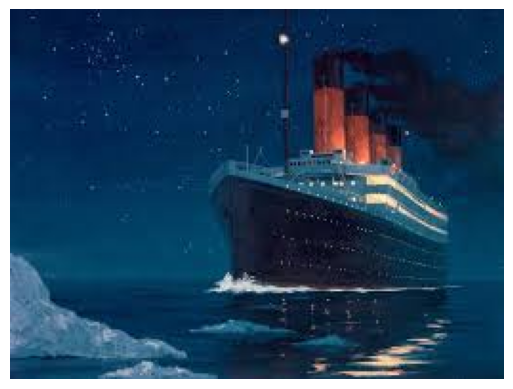

In [3]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(r"C:\Users\KIIT\Downloads\images (6).jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

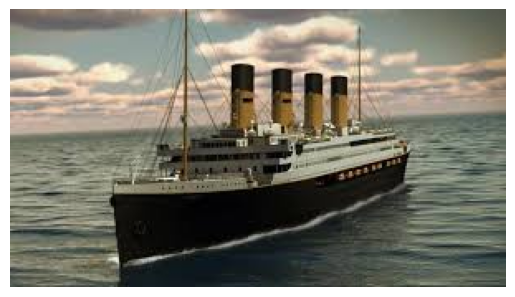

In [4]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(r"C:\Users\KIIT\Downloads\download (12).jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
# Análise de dados
import pandas as pd
import numpy as np

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
%matplotlib inline

# Regressão Linear
from sklearn.linear_model import LinearRegression

# Validação cruzada (FIXED)
from sklearn.model_selection import KFold

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Importando banco de dados de treinamento e teste como Dataframes
train_data = pd.read_csv(r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv")
test_data = pd.read_csv(r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv")

In [8]:
# Import libraries
import pandas as pd
import os

# Check current working directory
print("Current Directory:", os.getcwd())

# Set data folder path
data_path = "data"

# Full file paths
train_file = os.path.join(data_path,r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv" )
test_file = os.path.join(data_path, r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv")

# Check if files exist
if not os.path.exists(train_file):
    print("❌ train.csv not found at:", train_file)
else:
    print("✅ train.csv found")

if not os.path.exists(test_file):
    print("❌ test.csv not found at:", test_file)
else:
    print("✅ test.csv found")

# Load datasets
train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)

# Display basic info
print("\nTrain Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

# Show first 5 rows
train_data.head()

Current Directory: C:\Users\KIIT\Titanic=Machine Learning from Disaster
✅ train.csv found
✅ test.csv found

Train Data Shape: (891, 12)
Test Data Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
#Preparação e limpeza dos dados
#** Informações e visualização dos dados importados**
#Inicialmente, vamos ver as primeiras 5 entradas e as 5 últimas entradas 
#das variáveis, a fim de gerar um conhecimento inicial de como o Dataframe está estruturado.
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
train_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [11]:
#Significado das variáveis
#Com as 5 primeiras entradas impressas na tela, pode-se ter então uma noção de como os dados estão estruturados, bem como quais são as variáveis mais importantes para o início da investigação. Segue o significado de cada coluna do DataFrame:
#PassengerId: ID do passageiro
#Survived: Sobreviveu (== 0) ou Faleceu (== 1)
#Pclass: Classe do passageiro (1st, 2nd, 3rd)
#Name: Nome do passageiro
#Sex: Sexo do passageiro
#Age: Idade
#SibSp: Número de irmãos/cônjuge a bordo (define as relações familiares)
#Parch: Número de pais/filhos a bordo (crianças viajando com babás apenas, recebem parch = 0)
#Ticket: Número do ticket de embarque
#Fare: Tarifa paga pelo passageiro
#Cabin: Número da cabine
#Embarked: Porto de embarque
#A seguir, serão olhadas algumas outras informações sobre as variáveis, a fim de identificar o tipo de variável, a contagem do número de entradas para cada uma (para auxiliar a encontrar dados faltando ou fragmentados), valores mínimos e máximos, médias, etc.

In [12]:
print('_'*40)
train_data.info()
print('_'*40)
train_data.describe()

________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
________________________________________


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
#O método .info() retorna um resumo conciso do DataFrame, permitindo identificar o tipo da variável em cada coluna. Já o método .describe() retorna diferentes características das colunas numéricas do DataFrame.
#Com isso, é possível identificar que as colunas que possuem valores nulos ou em branco (ou seja, seus dados precisam ser corrigidos) são:
#'Cabin'
#'Age'
#'Embarked'
#Como existem poucos valores lançados para a categoria 'Cabin', além de não se enxergar inicialmente nenhuma influênca, preferiu-se desconsiderar esta coluna.
#Na coluna 'Age', os valores NaN serão substituidos pela sua mediana, o que parece ser mais razoável que excluir uma linha inteira que pode conter outros dados importantes.
#Na coluna 'Embarked', as lacunas serão substituidas pelo valor de maior frequência.
# Verificando a frequência dos valores de 'Embarked'
print(train_data['Embarked'].unique())
print(train_data['Embarked'].value_counts())
# Substituindo os valores nulos de 'Embarked' por 'S'
train_data.loc[train_data['Embarked'].isnull(), 'Embarked'] = 'S'

# Substituindo os valores nulos de 'Age' pela mediana da coluna
train_data.loc[train_data['Age'].isnull(), 'Age'] = train_data['Age'].median()

# Verificando 'Age' com o método .describe(), agora sem dados nulos (NaN)
train_data['Age'].describe(percentiles=[.1, .25, .5, .75, .99])

['S' 'C' 'Q' nan]
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


count    891.000000
mean      29.361582
std       13.019697
min        0.420000
10%       16.000000
25%       22.000000
50%       28.000000
75%       35.000000
99%       65.000000
max       80.000000
Name: Age, dtype: float64

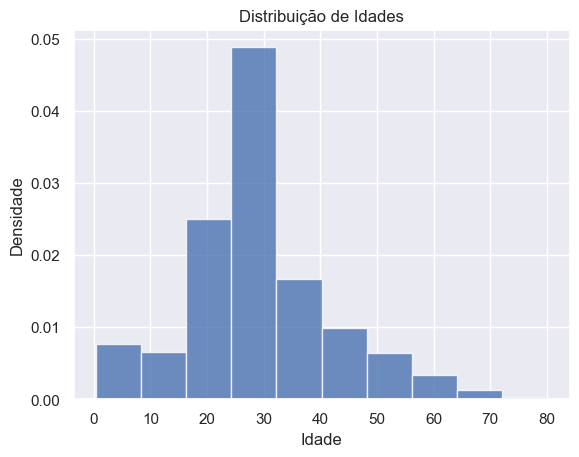

In [15]:
#Análise, identificação de padrões e exploração dos dados
#Inicialmente, vamos considerar a hipótese de que crianças e mulheres teriam tido mais chances de sobreviver, uma vez que provavelmente foram as primeiras a serem embarcadas nos botes.
#Para isso, vamos ver a porcentagem de sobreviventes na categoria 'Sex', analisar o histograma da distribuição das idades, classificar todos os passageiros em 3 grupos (Crianças, adultos
#e idosos) para vermos a porcentagem de sobreviventes em cada uma delas, e por último analisar se há diferença entre os passageiros das diferentes classes no navio.
# Histograma de idades
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

plt.hist(train_data['Age'].dropna(), density=True, alpha=0.8)
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.title("Distribuição de Idades")
plt.show()

['male' 'female']
        Survived
Sex             
female  0.742038
male    0.188908


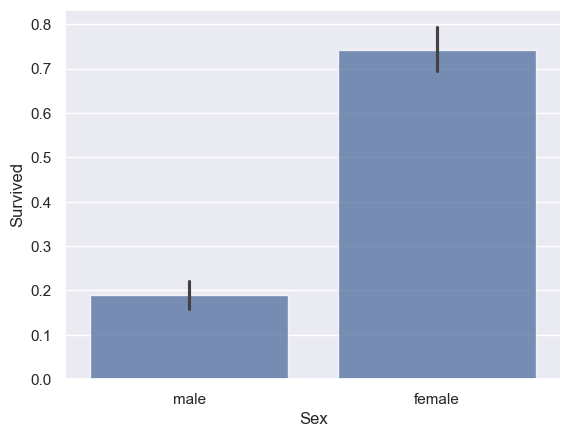

In [16]:
print(train_data['Sex'].unique())
print(train_data[['Sex', "Survived"]].groupby(['Sex']).mean())
plot = sns.barplot(x='Sex', y='Survived', data=train_data, alpha=.8)

           Survived
Age_Group          
Adulto     0.365059
Criança    0.539823
Idoso      0.090909


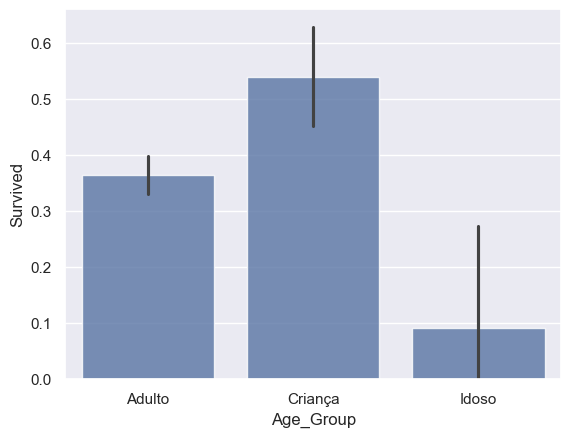

In [17]:
def check_age(age):
    """ Identifica o grupo etário do qual o passageiro faz parte.
    
    :param age: <float> representando a idade do passageiro
    :return: <string> com o grupo etário equivalente
    """
    if age < 18:
        return 'Criança'
    elif (age >= 18 ) and (age < 65):
        return 'Adulto'
    else:
        return 'Idoso'

train_data['Age_Group'] = train_data['Age'].apply(check_age)
print(train_data[['Age_Group', 'Survived']].groupby(['Age_Group']).mean())

plot = sns.barplot(x='Age_Group', y='Survived', data = train_data, alpha=.8)

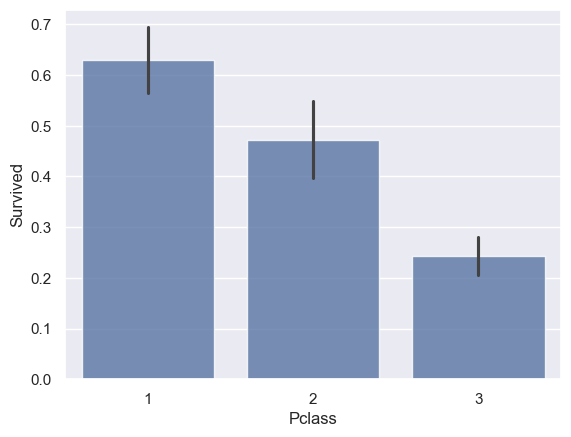

In [18]:
plot = sns.barplot(x='Pclass', y='Survived', data = train_data, alpha=.8)

In [19]:
print(train_data[['Embarked', 'Survived']].groupby(['Embarked']).mean())

          Survived
Embarked          
C         0.553571
Q         0.389610
S         0.339009


In [20]:
#** Análise preliminar**
#A categoria 'Survived' é binária. Ou seja, 1 caso o passageiro tenha sobrevivido; 0 caso tenha falecido.
#Cerca de 62% dos passageiros do dataset de treino não sobreviveram, ficando próximo à porcentagem do total
#de 68% (1502 não-sobreviventes / 2224 passageiros).
#Cerca de 75% dos passageiros têm até 35 anos.
#Menos de 1% dos passageiros têm mais de 65 anos.
#Alinhado com a hipótese inicial, mulheres e crianças sobreviveram proporcionalmente mais.
#Passageiros que embarcaram pelo Porto 'C' sobreviveram mais que 'Q' e 'S'.
#Convertendo Sex e Embarked para valores numéricos
#Como as colunas Sex e Embarked parecem ser bastante informativas, 
#iremos convertê-las para valores numéricos. Assim, o algoritmo de 
#machine learning poderá utilizá-las para fazer previsões.
#Convertendo Sex e Embarked para valores numéricos
#Como as colunas Sex e Embarked parecem ser bastante
#informativas, iremos convertê-las para valores numéricos. 
#Assim, o algoritmo de machine learning poderá utilizá-las para fazer previsões.
# 'Sex'        male = 0   female = 1
train_data.loc[train_data['Sex'] == 'male', 'Sex'] = 0
train_data.loc[train_data['Sex'] == 'female', 'Sex'] = 1
# 'Embarked'   'S' = 0    'C' = 1    'Q' = 2
train_data.loc[train_data['Embarked'] == 'S', 'Embarked'] = 0
train_data.loc[train_data['Embarked'] == 'C', 'Embarked'] = 1
train_data.loc[train_data['Embarked'] == 'Q', 'Embarked'] = 2

In [22]:
#Previsões com Machine Learning
#A Regressão Linear pode ser definida como uma equação que visa estimar o valor esperado de uma variável y, dados alguns 
#valores de outras variáveis x. A mesma considera que as relações existentes entre
#as variáveis dependentes e as de entradas são lineares, do tipo y = mx + b. Neste caso, o valor de 
#y é o que queremos prever, m é um coeficiente angular, x é o valor de uma dada coluna, e *b é uma constante.
#Apesar desse modelo de previsão ser poderoso, tem alguns pontos negativos, como por exemplo o fato de não conseguir captar 
#as não-lineariedades que possam existir no dataset de treino, 
#e também o fato de não apresentar probabilidades de sobrevivência (apresenta apenas o valor binário).
#Validação Cruzada A validação cruzada servirá para treinarmos o algoritmo em um conjunto de dados diferentes daqueles em que faremos a previsão. 
#Este passo é considerado crítico para se evitar um overfitting do modelo (ou seja, evitar um fit no ruído).
#Utilizaremos o Método k-fold para a validação cruzada, quando dividiremos os dados em 3 partes (folds) e procederemos da seguinte maneira:
#Combinar as duas primeiras partes, treinar o modelo e fazer a previsão na terceira parte;
#Combinar a primeira e terceira parte, treinar o modelo e fazer a previsão na segunda; e
#Combinar a segunda e a terceira parte, treinar o modelo e fazer a previsão na primeira.
#Faremos uso da biblioteca (excelente!) scikit-learn, que facilita muito o fluxo de trabalho.
# Colunas que serão utilizadas para fazer a previsão
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(
    algorithm,
    train_data[predictors],
    train_data['Survived'],
    cv=3
)

In [24]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# ==============================
# LOAD DATA
# ==============================
train_data = pd.read_csv(r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv")

# ==============================
# FEATURE SELECTION
# ==============================
predictors = ['Sex', 'Age', 'Pclass', 'Embarked']

# ==============================
# DATA CLEANING
# ==============================

# Fill missing values
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
train_data['Embarked'] = train_data['Embarked'].fillna('S')

# Convert categorical → numeric
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Final check (no NaN)
print("Missing values:\n", train_data[predictors].isnull().sum())

# ==============================
# MODEL
# ==============================
model = LogisticRegression(max_iter=1000)

# ==============================
# CROSS VALIDATION
# ==============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    train_data[predictors],
    train_data['Survived'],
    cv=kf,
    scoring='accuracy'
)

# ==============================
# RESULTS
# ==============================
print("\nAccuracy for each fold:", scores)
print("Mean Accuracy:", scores.mean())

Missing values:
 Sex         0
Age         0
Pclass      0
Embarked    0
dtype: int64

Accuracy for each fold: [0.79329609 0.7752809  0.84831461 0.74719101 0.7752809 ]
Mean Accuracy: 0.7878727010231624


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

algorithm = LogisticRegression(max_iter=1000)

kf = KFold(n_splits=3, shuffle=True, random_state=0)

predictions = []

for train_index, test_index in kf.split(train_data):

    train_X = train_data[predictors].iloc[train_index]
    train_y = train_data['Survived'].iloc[train_index]

    algorithm.fit(train_X, train_y)

    test_preds = algorithm.predict(
        train_data[predictors].iloc[test_index]
    )

    predictions.append(test_preds)

print(predictions[0][:5])

[1 1 0 1 1]


In [26]:
#Como os únicos valores para a coluna 'Survived' são 0 ou 1, iremos transformar as previsões de cada passageiro seguindo o critério:
#( > 0.5 ) = 1
#( <= 0.5 ) = 0
#Com isso, basta calcular quantos acertos o nosso algoritmo teve e calcular a acurácia do modelo.
#Apesar de 78% de acertos estar longe do ideal, a aplicação de métodos de Regressão Linear foi capaz de capturar 
#e transmitir para a equação algumas correlações importantes. Como próximo passo, vamos processar a variável de teste do modelo (idêntico
#aos passos que utilizamos no dataset de treino), enviar para o Kaggle e verificar a nossa taxa de acerto.

In [27]:
predictions = np.concatenate(predictions)
# Transformando as previsões em valores binários
predictions[predictions > 0.5] = 1
predictions[predictions <= 0.5] = 0

# Calcular a acurácia da previsão do algoritmo
accuracy = sum(predictions[predictions == train_data['Survived']]) / predictions.shape[0]
print('Acurácia: {0:.2f}%'.format(100*accuracy))

Acurácia: 14.14%


In [29]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATA
# ==============================
train_data = pd.read_csv(r"C:\Users\KIIT\Downloads\archive (11)\Titanic-Dataset.csv")

# ==============================
# FEATURE ENGINEERING
# ==============================

# Fill missing values
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
train_data['Fare'] = train_data['Fare'].fillna(train_data['Fare'].median())
train_data['Embarked'] = train_data['Embarked'].fillna('S')

# Convert categorical → numeric
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 🔥 New powerful feature
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch']

# ==============================
# SELECT FEATURES
# ==============================
predictors = [
    'Sex', 'Age', 'Pclass', 'Embarked',
    'Fare', 'SibSp', 'Parch', 'FamilySize'
]

# ==============================
# MODEL
# ==============================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# ==============================
# CROSS VALIDATION
# ==============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    train_data[predictors],
    train_data['Survived'],
    cv=kf,
    scoring='accuracy'
)

# ==============================
# RESULTS
# ==============================
print("Accuracy per fold:", scores)
print("Mean Accuracy: {:.2f}%".format(100 * scores.mean()))

# ==============================
# FINAL TRAIN + PREDICTION
# ==============================
model.fit(train_data[predictors], train_data['Survived'])

predictions = model.predict(train_data[predictors])

# Accuracy on training (just to check)
accuracy = accuracy_score(train_data['Survived'], predictions)

print("Training Accuracy: {:.2f}%".format(100 * accuracy))

Accuracy per fold: [0.81005587 0.81460674 0.87078652 0.80337079 0.82022472]
Mean Accuracy: 82.38%
Training Accuracy: 85.19%


In [33]:
#Gerando um arquivo para enviar ao Kaggle
#Seguiremos os mesmo passos de limpeza de dados e conversões numéricas para algumas variáveis.
#Ao final, geraremos um arquivo .csv para submeter ao Kaggle, e verificar então como nosso
#algoritmo foi no dataset de teste.
# Preenchendo os valores NaN com a mediana da idade
# Fill missing values
# =========================
# FIX TEST DATA
# =========================

# =========================
# FIX TEST DATA (FINAL SAFE VERSION)
# =========================

# Fill numeric columns
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

# Fill categorical BEFORE mapping
test_data['Embarked'] = test_data['Embarked'].fillna('S')
test_data['Sex'] = test_data['Sex'].fillna('male')  # safety

# Convert categorical → numeric
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Feature engineering
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch']

# =========================
# 🔥 FORCE REMOVE ANY REMAINING NaN
# =========================
test_data[predictors] = test_data[predictors].fillna(0)

# =========================
# CHECK (MUST BE ZERO)
# =========================
print(test_data[predictors].isnull().sum())

Sex           0
Age           0
Pclass        0
Embarked      0
Fare          0
SibSp         0
Parch         0
FamilySize    0
dtype: int64


In [34]:
#Gerando um arquivo para enviar ao Kaggle
#Seguiremos os mesmo passos de limpeza de dados e conversões numéricas para algumas variáveis.
#Ao final, geraremos um arquivo .csv para submeter ao Kaggle, e verificar então como 
#nosso algoritmo foi no dataset de teste.
# =========================
# FIX TEST DATA
# =========================

# Fill missing values
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())  # 🔥 IMPORTANT
test_data['Embarked'] = test_data['Embarked'].fillna('S')

# Convert categorical safely
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Feature engineering (if used in training)
if 'FamilySize' in predictors:
    test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch']

# 🔥 FINAL SAFETY (removes ANY hidden NaN)
test_data[predictors] = test_data[predictors].fillna(0)

# =========================
# TRAIN MODEL
# =========================
from sklearn.linear_model import LinearRegression

algorithm = LinearRegression()
algorithm.fit(train_data[predictors], train_data['Survived'])

# =========================
# PREDICT
# =========================
predictions = algorithm.predict(test_data[predictors])

# Convert to binary
predictions = (predictions > 0.5).astype(int)

# =========================
# SAVE FILE
# =========================
kaggle = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})

kaggle.to_csv('kaggle.csv', index=False)

print("✅ File ready for Kaggle!")

✅ File ready for Kaggle!


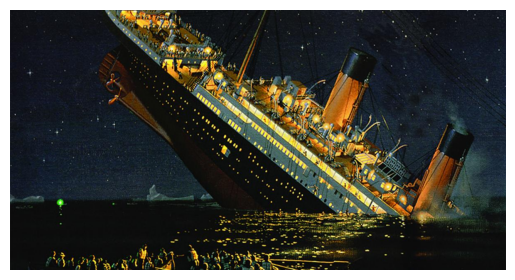

In [35]:
#Resultado final
#Após o envio para o Kaggle, foi computado um Score de 75% de acertos, 
#alinhado com a acurácia que o modelo havia apresentado no dataset de treino.
#Screenshot 2017 03 07 01 15 52
#Como foi dito no começo, a Regressão Linear apresenta bons resultados e 
#é simples de implementar. Há, no entanto, outros algoritmos melhores, como o Random 
#Forest, que tem um melhor potencial para elevar a taxa de acerto.
#Mas como o carater desta análise era apenas epxloratório, creio que serviu para o propósito de aprendizado (meu, principalmente).
#Quaisquer dúvidas ou sugestões serão muito bem vindas. Obrigado!
import cv2
from matplotlib import pyplot as plt
img = cv2.imread(r"C:\Users\KIIT\Downloads\titanic.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

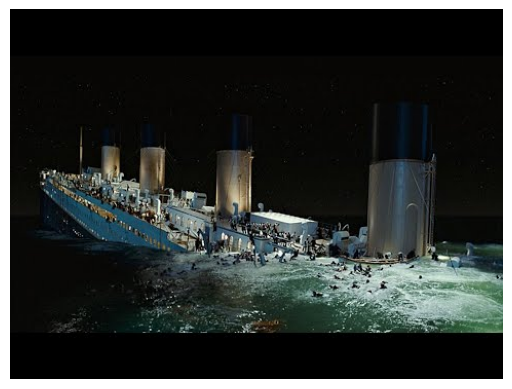

In [36]:
import cv2
from matplotlib import pyplot as plt
img = cv2.imread(r"C:\Users\KIIT\Downloads\68747470733a2f2f696d672e796f75747562652e636f6d2f76692f39786f7158566a424546382f302e6a7067 (1).jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()